# Step Limits and Cost Budgets

Bounding step count, token spend, and wall-clock time inside a LangGraph agent loop with a budget-aware LLM that adapts when the bounds get tight.

| Primitive | What it is | Why |
|-----------|------------|----------------|
| `BudgetState` (TypedDict) | Carries `steps_used`, `tokens_used`, `deadline_ts`, `trace`, `terminated_reason` | The single shared state every node reads and writes |
| `BudgetConfig` (Pydantic) | `max_steps`, `max_tokens`, `max_seconds` per run | One immutable config object instead of three globals |
| `time.monotonic()` | Steady wall-clock counter immune to NTP jumps | The right primitive for a deadline |
| `response.usage_metadata` | LangChain's standard `input_tokens` / `output_tokens` field on `AIMessage` | Real token accounting, not a heuristic |
| `StateGraph` | LangGraph state-machine container | The bounded loop is a graph with a check-budget gate |

We will see how an agent loop respects three independent bounds, step cap, token budget, and time limit; and how a budget-aware prompt lets the LLM shorten its own answer when those bounds get tight.

## Setup

Let's define the shared task we will keep re-running.

Now, we will
- declare a single `TASK` string used by every demo run so the only thing varying between runs is the `BudgetConfig`,
- define a tiny `count_tokens(msg)` helper that prefers `response.usage_metadata` and falls back to a word-count estimate when a provider omits it.

In [1]:
# !pip install -q langchain langchain-google-genai langchain-openai langchain-anthropic langgraph langchain-community

from langchain.chat_models import init_chat_model
from langchain.embeddings import init_embeddings
from langchain_core.messages import AIMessage
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Optional
from pydantic import BaseModel, Field
import os, json, time

from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# os.environ['GEMINI_API_KEY']  # the variable for API key

llm   = init_chat_model('gpt-4o', model_provider='openai', temperature=0)
# llm   = init_chat_model('gemini-2.5-flash', model_provider='google_genai', temperature=0)

embed = init_embeddings('sentence-transformers/all-MiniLM-L6-v2', provider='huggingface')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Now the shared task. We want something that the LLM could expand on for many turns; that way a tight budget produces a visibly different output from a generous one. The same `TASK` string is fed to every variant in the demo so the only independent variable is the `BudgetConfig`.

In [3]:
TASK = (
    'Write a short summary of how LangGraph manages agent state across nodes, edges, '
    'and checkpointing. Refine the summary across multiple iterations.'
)
print('TASK:', TASK)

TASK: Write a short summary of how LangGraph manages agent state across nodes, edges, and checkpointing. Refine the summary across multiple iterations.


And the token-counting helper. LangChain attaches `usage_metadata` to every `AIMessage` for the providers that report it (`input_tokens`, `output_tokens`, `total_tokens`). 

When a provider omits it (older Ollama models, some local backends) we fall back to `len(text.split()) * 1.3`, which is precise enough for a small demo. The whole notebook reads tokens through this single function.

In [4]:
def count_tokens(msg: AIMessage) -> int:
    """Return total tokens for an AIMessage. Prefer response.usage_metadata
    (LangChain attaches it on AIMessage), else fall back to a word-count estimate."""
    meta = getattr(msg, 'usage_metadata', None)
    if meta:
        # usage_metadata is a dict with input_tokens / output_tokens / total_tokens.
        return int(meta.get('total_tokens') or
                   (meta.get('input_tokens', 0) + meta.get('output_tokens', 0)))
    text = getattr(msg, 'content', '') or ''
    return int(len(text.split()) * 1.3)

probe = llm.invoke('Say hello in five words.')
print('probe content :', probe.content[:120] + '...')
print('probe tokens  :', count_tokens(probe))

probe content : Hello, how are you today?...
probe tokens  : 20


*Tip: track `input_tokens` and `output_tokens` separately when you wire this into a real bill. Output tokens are typically 3-5x more expensive on most APIs. The `total_tokens` field is fine for a budget gate but hides that ratio.*

## The three bounds an agent loop must respect

Let's name the three families of bounds before we wire anything. Every production agent needs all three; each defends a different failure mode.

Now, we will
- introduce the **step cap** as a counter incremented inside a graph node (the `recursion_limit` keyword arg is a related primitive but a counter inside state is auditable from the trace),
- introduce the **token budget** as a cumulative sum of `usage_metadata.total_tokens` across every LLM call,
- introduce the **time limit** as a `time.monotonic()` deadline timestamp computed once at the start of the run,
- print a tiny demo that shows each primitive in isolation so the later capstone cell has nothing left to surprise us.

In [5]:
# Step cap demo — a counter incremented per node execution.
steps_used = 0
MAX_STEPS_DEMO = 3
for _ in range(5):
    steps_used += 1
    if steps_used >= MAX_STEPS_DEMO:
        print(f'step cap hit at steps_used={steps_used}')
        break

step cap hit at steps_used=3


Token budget next. We sum `usage_metadata.total_tokens` (read via `count_tokens`) across the calls and compare against a `max_tokens` cap.

In [6]:
tokens_used = 0
MAX_TOKENS_DEMO = 60
for prompt in ['Name two birds.', 'Name two more birds.']:
    msg = llm.invoke(prompt)
    tokens_used += count_tokens(msg)
    print(f'  call -> +{count_tokens(msg):>3} tokens, cumulative={tokens_used}')
    if tokens_used >= MAX_TOKENS_DEMO:
        print(f'token budget hit at tokens_used={tokens_used}')
        break

  call -> + 22 tokens, cumulative=22
  call -> + 31 tokens, cumulative=53


And the time limit. `time.monotonic()` returns a steady float that never goes backwards (unlike `time.time()` which can jump on NTP corrections). We compute the deadline once and compare on every node entry.

In [7]:
deadline_ts = time.monotonic() + 0.5  # 500 ms budget
ticks = 0
while True:
    ticks += 1
    if time.monotonic() >= deadline_ts:
        print(f'time limit hit after {ticks} ticks')
        break
    time.sleep(0.1)

time limit hit after 6 ticks


## `BudgetConfig` and `BudgetState`

Now let's promote those three loose primitives into one immutable config object plus one shared state schema.

Now, we will
- declare a Pydantic `BudgetConfig` with `max_steps`, `max_tokens`, `max_seconds`, validated by `Field(ge=...)`,
- declare a `BudgetState` `TypedDict` carrying `task`, `steps_used`, `tokens_used`, `deadline_ts`, `trace`, `answer`, `terminated_reason`,
- write a `make_initial_state(task, cfg)` helper that converts a config into the deadline timestamp via `time.monotonic() + cfg.max_seconds`,
- print one example state so the field shapes are visible.

In [8]:
class BudgetConfig(BaseModel):
    """One immutable budget per run. Three bounds, three Field constraints.
    Using a Pydantic model (not three loose ints) makes the WHOLE budget a single
    auditable object you can log, version, and pass through a graph config."""
    max_steps:   int   = Field(ge=1, description='Maximum node executions before forced termination')
    max_tokens:  int   = Field(ge=1, description='Cumulative input+output token cap across all LLM calls')
    max_seconds: float = Field(gt=0, description='Wall-clock deadline measured from run start')

The schema is the contract. `Field(ge=1)` rules out the silent off-by-one where `max_steps=0` makes the loop never run. Validation happens at construction time, not deep inside a node call.

In [9]:
class BudgetState(TypedDict):
    task:               str
    steps_used:         int
    tokens_used:        int
    deadline_ts:        float           # absolute time.monotonic() value
    trace:              List[dict]      # first-class audit log of every node entry
    answer:             str             # best-so-far answer; written by work_node
    terminated_reason:  Optional[str]   # None until check_budget_node trips a bound

`trace` is a first-class field of state, debugging reads the same audit log the runtime does. `terminated_reason` starts as `None` and is set by `check_budget_node` to one of `'step_cap'` / `'token_budget'` / `'time_limit'` when that bound is breached.

In [10]:
def make_initial_state(task: str, cfg: BudgetConfig) -> BudgetState:
    """Convert a BudgetConfig into a fresh BudgetState. The deadline is computed
    ONCE here, not on every node call — that way the time bound is a fixed point,
    not a moving target."""
    return {
        'task':              task,
        'steps_used':        0,
        'tokens_used':       0,
        'deadline_ts':       time.monotonic() + cfg.max_seconds,
        'trace':             [],
        'answer':            '',
        'terminated_reason': None,
    }

demo_cfg = BudgetConfig(max_steps=4, max_tokens=2000, max_seconds=10.0)
demo_state = make_initial_state(TASK, demo_cfg)
print('demo_cfg   :', demo_cfg.model_dump())
print('demo_state :', {k: demo_state[k] for k in ('steps_used','tokens_used','terminated_reason')})

demo_cfg   : {'max_steps': 4, 'max_tokens': 2000, 'max_seconds': 10.0}
demo_state : {'steps_used': 0, 'tokens_used': 0, 'terminated_reason': None}


## `check_budget_node` and `work_node`

Next, the two nodes the graph alternates between. `check_budget_node` is the gate; `work_node` is the LLM call.

Now, we will
- write a budget-aware prompt template that tells the LLM how many steps and roughly how many tokens it has left,
- implement `work_node` to format that prompt, call `llm.invoke`, read `usage_metadata` via `count_tokens`, and increment `steps_used` / `tokens_used`,
- implement `check_budget_node` to compare current state against all three bounds and write `terminated_reason` when any is breached,
- write a tiny `route_after_check` function used as the conditional edge: `terminated_reason is not None → END`, else continue.

In [11]:
BUDGET_AWARE_PROMPT = """You are a budget-aware assistant.

Task: {task}

Budget remaining:
- steps : {steps_left}
- tokens: ~{tokens_left}
- seconds: {seconds_left:.1f}

Current draft:
{prior}

Adapt your behaviour to the remaining budget:
- If the budget is TIGHT, skip optional sub-questions, summarise sooner, and exit early with a partial answer plus a brief caveat.
- If the budget is GENEROUS, refine the draft thoroughly.
Return ONLY the improved draft (no preamble).
"""

In [12]:
def work_node(state: BudgetState, cfg: BudgetConfig) -> dict:
    """One unit of work. Increments steps_used, calls the LLM with a budget-aware prompt,
    reads usage_metadata for real token accounting, and appends to the trace. Returns ONLY
    the fields that change so LangGraph can merge them into state."""
    steps_left   = cfg.max_steps   - state['steps_used']
    tokens_left  = cfg.max_tokens  - state['tokens_used']
    seconds_left = max(0.0, state['deadline_ts'] - time.monotonic())
    prior = state['answer'] or '(nothing yet)'

    prompt = BUDGET_AWARE_PROMPT.format(
        task=state['task'], steps_left=steps_left,
        tokens_left=tokens_left, seconds_left=seconds_left, prior=prior,
    )
    msg = llm.invoke(prompt)
    used = count_tokens(msg)

    trace = state['trace'] + [{
        'event':        'work',
        'step':         state['steps_used'] + 1,
        'tokens_call':  used,
        'tokens_total': state['tokens_used'] + used,
        'seconds_left': round(seconds_left, 2),
    }]
    return {
        'steps_used':  state['steps_used']  + 1,
        'tokens_used': state['tokens_used'] + used,
        'answer':      msg.content,
        'trace':       trace,
    }

`work_node` takes the config as a second argument. We will partially-apply it when registering the node so LangGraph still calls a single-argument function. That keeps the node pure with respect to state and makes the per-run budget visible in the graph wiring rather than hidden in a global.

In [13]:
def check_budget_node(state: BudgetState, cfg: BudgetConfig) -> dict:
    """Pure gate. Examines current steps_used, tokens_used, and time.monotonic() vs
    deadline_ts. Returns {'terminated_reason': ...} when any bound is exceeded; otherwise
    returns {} so state passes through untouched."""
    if state['steps_used'] >= cfg.max_steps:
        return {'terminated_reason': 'step_cap',
                'trace': state['trace'] + [{'event': 'check', 'verdict': 'step_cap'}]}
    if state['tokens_used'] >= cfg.max_tokens:
        return {'terminated_reason': 'token_budget',
                'trace': state['trace'] + [{'event': 'check', 'verdict': 'token_budget'}]}
    if time.monotonic() >= state['deadline_ts']:
        return {'terminated_reason': 'time_limit',
                'trace': state['trace'] + [{'event': 'check', 'verdict': 'time_limit'}]}
    return {'trace': state['trace'] + [{'event': 'check', 'verdict': 'ok'}]}

One central gate is easier to audit than three checks scattered through every node. The order of checks above is also the priority order.

If step cap and time limit fire on the same call, we report `step_cap` (the cheaper failure). Pick the order to match the bound you most want surfaced in alerts.

In [14]:
def route_after_check(state: BudgetState) -> str:
    """Conditional edge. terminated_reason is not None -> END; else loop back to work."""
    return 'end' if state['terminated_reason'] is not None else 'work'

print('check_budget_node and work_node defined; routing function ready.')

check_budget_node and work_node defined; routing function ready.


## Compiling the bounded loop

Time to assemble the StateGraph and bind a per-run `BudgetConfig` into the two nodes.

Now, we will
- write a `build_graph(cfg)` factory that closes over the config and registers `check_budget_node` then `work_node`,
- wire edges so the loop is `START → check → (END | work) → check → ...`,
- compile the graph and render its mermaid diagram via the bare-cell trick,
- print the node list as a sanity check.

In [15]:
def build_graph(cfg: BudgetConfig):
    """Bind cfg into the two nodes, wire the loop, compile.
    The factory pattern keeps cfg out of state while still letting each run pick its own bounds."""
    builder = StateGraph(BudgetState)
    builder.add_node('check', lambda s: check_budget_node(s, cfg))
    builder.add_node('work',  lambda s: work_node(s, cfg))

    builder.add_edge(START, 'check')
    builder.add_conditional_edges('check', route_after_check, {'work': 'work', 'end': END})
    builder.add_edge('work', 'check')
    return builder.compile()

demo_app = build_graph(demo_cfg)
print('Graph compiled with nodes:', list(demo_app.get_graph().nodes))

Graph compiled with nodes: ['__start__', 'check', 'work', '__end__']


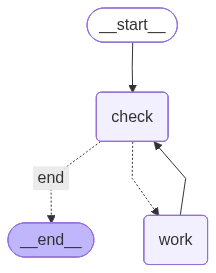

In [16]:
demo_app

## Side-by-side: same task, three configs

Now let's run the SAME `TASK` three times, varying only the `BudgetConfig`. The trace plus `terminated_reason` should make it obvious which bound tripped.

Now, we will
- define a `run_one(label, cfg)` helper that builds the graph, invokes it, and returns a small result dict,
- run a **generous** config that completes via the step cap with the agent producing a polished answer,
- run a **tight step cap** (`max_steps=2`) so the loop terminates after two work calls,
- run a **tight time limit** (`max_seconds=0.5`) so the deadline fires inside the first or second call,
- print each run showing the trace and `terminated_reason`.

In [17]:
def run_one(label: str, cfg: BudgetConfig) -> dict:
    """Build a graph for cfg, invoke it on TASK, return a tidy result row.
    We set recursion_limit high so OUR check_budget_node always trips first, never LangGraph's."""
    app = build_graph(cfg)
    init = make_initial_state(TASK, cfg)
    t0 = time.monotonic()
    out = app.invoke(init, config={'recursion_limit': 50})
    elapsed = time.monotonic() - t0
    return {
        'label':             label,
        'cfg':               cfg.model_dump(),
        'steps_used':        out['steps_used'],
        'tokens_used':       out['tokens_used'],
        'elapsed':           round(elapsed, 2),
        'terminated_reason': out['terminated_reason'],
        'trace':             out['trace'],
        'answer':            out['answer'],
    }

First the generous run. We set `max_steps=3` so the loop completes via the step cap with a clean, polished answer.

In [18]:
generous = run_one('GENEROUS', BudgetConfig(max_steps=3, max_tokens=20000, max_seconds=60.0))

print('---- GENEROUS ----')
print('terminated_reason:', generous['terminated_reason'])
print('steps_used       :', generous['steps_used'])
print('tokens_used      :', generous['tokens_used'])
print('elapsed (s)      :', generous['elapsed'])
print('answer preview   :', generous['answer'][:120] + '...')

---- GENEROUS ----
terminated_reason: step_cap
steps_used       : 3
tokens_used      : 827
elapsed (s)      : 5.04
answer preview   : LangGraph efficiently manages agent state by distributing it across nodes and edges within a network. Each node represen...


Now the tight step cap. `max_steps=2` means the loop runs `work_node` twice and `check_budget_node` trips on the third entry. The budget-aware prompt also sees `steps_left` shrink and shifts toward a more decisive answer.

In [19]:
tight_steps = run_one('TIGHT_STEPS', BudgetConfig(max_steps=2, max_tokens=20000, max_seconds=60.0))

print('---- TIGHT_STEPS ----')
print('terminated_reason:', tight_steps['terminated_reason'])
print('steps_used       :', tight_steps['steps_used'])
print('tokens_used      :', tight_steps['tokens_used'])
print('elapsed (s)      :', tight_steps['elapsed'])
print('answer preview   :', tight_steps['answer'][:120] + '...')

---- TIGHT_STEPS ----
terminated_reason: step_cap
steps_used       : 2
tokens_used      : 524
elapsed (s)      : 3.87
answer preview   : LangGraph effectively manages agent state by distributing it across nodes and edges within its network. Each node repres...


And the tight time limit. `max_seconds=0.5` is well below the wall-clock cost of a single Gemini call, so `check_budget_node` trips by the deadline within the first iteration or two.

In [20]:
tight_time = run_one('TIGHT_TIME', BudgetConfig(max_steps=10, max_tokens=20000, max_seconds=0.5))

print('---- TIGHT_TIME ----')
print('terminated_reason:', tight_time['terminated_reason'])
print('steps_used       :', tight_time['steps_used'])
print('tokens_used      :', tight_time['tokens_used'])
print('elapsed (s)      :', tight_time['elapsed'])
print('answer preview   :', (tight_time['answer'] or '(empty)')[:120] + '...')

---- TIGHT_TIME ----
terminated_reason: time_limit
steps_used       : 1
tokens_used      : 226
elapsed (s)      : 2.09
answer preview   : LangGraph efficiently manages agent state by distributing it across nodes and edges within its network. Each node repres...


Finally the consolidated trace dump. Each row shows what the gate saw and what the work node spent. This is the same audit log a production observability stack would parse.

In [21]:
print('=== TRACES ===')
for run in (generous, tight_steps, tight_time):
    print(f"\n---- {run['label']} ({run['terminated_reason']}) ----")
    for step in run['trace']:
        print(' ', json.dumps(step))

print('\n=== SUMMARY ===')
for run in (generous, tight_steps, tight_time):
    print(f"  {run['label']:<12} reason={str(run['terminated_reason']):<14} "
          f"steps={run['steps_used']} tokens={run['tokens_used']} elapsed={run['elapsed']}s")

=== TRACES ===

---- GENEROUS (step_cap) ----
  {"event": "check", "verdict": "ok"}
  {"event": "work", "step": 1, "tokens_call": 223, "tokens_total": 223, "seconds_left": 60.0}
  {"event": "check", "verdict": "ok"}
  {"event": "work", "step": 2, "tokens_call": 304, "tokens_total": 527, "seconds_left": 58.06}
  {"event": "check", "verdict": "ok"}
  {"event": "work", "step": 3, "tokens_call": 300, "tokens_total": 827, "seconds_left": 56.67}
  {"event": "check", "verdict": "step_cap"}

---- TIGHT_STEPS (step_cap) ----
  {"event": "check", "verdict": "ok"}
  {"event": "work", "step": 1, "tokens_call": 222, "tokens_total": 222, "seconds_left": 60.0}
  {"event": "check", "verdict": "ok"}
  {"event": "work", "step": 2, "tokens_call": 302, "tokens_total": 524, "seconds_left": 57.53}
  {"event": "check", "verdict": "step_cap"}

---- TIGHT_TIME (time_limit) ----
  {"event": "check", "verdict": "ok"}
  {"event": "work", "step": 1, "tokens_call": 226, "tokens_total": 226, "seconds_left": 0.5}
  {

### Designing budgets in production
- Set ALL three bounds explicitly on every graph, even in development. `max_steps` alone is a weak proxy for cost; `max_tokens` alone does not bound latency; `max_seconds` alone does not bound spend.
- Track `input_tokens` and `output_tokens` separately when the budget feeds a real bill; output tokens are typically 3-5x more expensive on most APIs. <br>Mitigation: store both fields in `trace` and only sum them for the gate check.
- Use `time.monotonic()` for deadlines, not `time.time()`. The latter can jump backwards on NTP correction and silently extend or truncate your wall-clock budget.
- Pick the priority order in `check_budget_node` to match what you most want to alert on. The first bound checked is the one that gets the blame.

### Common pitfalls in budget-aware loops
- Telling the model `you have 50 tokens left` makes it rush and produce worse output than it would otherwise. Only inject remaining budget into the prompt when at least 2-3 iterations of meaningful work remain.
- `recursion_limit` on `StateGraph.invoke` counts node executions, not LLM calls. A graph with cheap dispatcher nodes can hit the limit without any LLM activity; set it at 2-3x the per-bound cap so YOUR `check_budget_node` always trips first.
- `usage_metadata` may be missing on some providers and on streaming responses. Always have a fallback estimator (`len(text.split()) * 1.3` is fine for teaching) and log when the fallback fires.
- Compute `deadline_ts` ONCE in `make_initial_state`, never inside `work_node`. A deadline recomputed on every entry quietly resets the budget and the time bound stops working.